#Objective
#Build a machine learning model to predict whether a loan applicant will default, using the Home Credit application data.
#Business goal: Help a lender identify higher-risk borrowers more accurately than using simple rules alone.
#Models compared: Logistic Regression vs. XGBoost
#Key evaluation metrics: ROC-AUC vs. Precision-Recall AUC vs. Confusion Matrix




In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier


In [5]:
train_df = pd.read_csv('/kaggle/input/datasets/megancrenshaw/home-credit-default-risk/home-credit-default-risk/application_train.csv')
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
train_df['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Target Distribution

The dataset is highly imbalanced, with approximately 92% of observations corresponding to non-defaults and only 8% to defaults.

This imbalance implies that accuracy alone would be a misleading performance metric, as a naive model predicting all observations as non-default would achieve high accuracy but provide no predictive value.

Therefore, more appropriate evaluation metrics such as ROC-AUC and precision-recall AUC will be used.

In [9]:
train_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [12]:
X = train_df.copy()

X['DAYS_EMPLOYED'] = X['DAYS_EMPLOYED'].replace(365243, np.nan)

In [13]:
train_df.isnull().mean().sort_values(ascending=False).head(10)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
dtype: float64

In [14]:
missing_pct = train_df.isnull().mean()

high_missing_cols = missing_pct[missing_pct > 0.6].index.tolist()

print("Columns to drop:", len(high_missing_cols))
high_missing_cols[:10]

Columns to drop: 17


['OWN_CAR_AGE',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'FLOORSMIN_AVG',
 'LIVINGAPARTMENTS_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'FLOORSMIN_MODE',
 'LIVINGAPARTMENTS_MODE']

In [16]:
df = train_df.drop(columns=high_missing_cols)

Columns with more than 60% missing values were removed from the dataset. These variables are unlikely to provide reliable predictive signal and may introduce noise when imputed.

Remaining missing values will be handled using imputation within the modeling pipeline.

In [17]:
df = df.drop(columns=['SK_ID_CURR'], errors='ignore')

X = df.drop(columns=['TARGET'])
y = df['TARGET']

In [18]:
X.shape, y.shape

((307511, 103), (307511,))

In [19]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

len(categorical_cols), len(numeric_cols)

(15, 88)

In [20]:
train_df = pd.read_csv('/kaggle/input/datasets/megancrenshaw/home-credit-default-risk/home-credit-default-risk/application_train.csv')

missing_pct = train_df.isnull().mean()
high_missing_cols = missing_pct[missing_pct > 0.6].index.tolist()

df = train_df.drop(columns=high_missing_cols)

df = df.drop(columns=['SK_ID_CURR'], errors='ignore')

X = df.drop(columns=['TARGET'])
y = df['TARGET']

X.shape, y.shape

((307511, 103), (307511,))

In [21]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

len(categorical_cols), len(numeric_cols)

(15, 88)

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_valid.shape

((246008, 103), (61503, 103))

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [25]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'FLAG_MOBIL'...
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'WEEKDAY_APPR_PROCESS_START',
                                                   'ORGANIZATION_TYPE',
                                                   'HOUSETYPE_MODE',
                                                   'WALLSMATERIAL_MODE',
                                                   'EMERGENCYSTATE_MODE'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [26]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

log_probs = log_model.predict_proba(X_valid)[:, 1]
log_preds = (log_probs >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_valid, log_probs))
print("PR-AUC:", average_precision_score(y_valid, log_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, log_preds))

print("\nClassification Report:")
print(classification_report(y_valid, log_preds))

ROC-AUC: 0.7484619154984106
PR-AUC: 0.2284992671523009

Confusion Matrix:
[[39107 17431]
 [ 1603  3362]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



The Logistic Regression model achieved a ROC-AUC of approximately 0.75, indicating good discriminatory power between defaulting and non-defaulting borrowers.

The precision-recall AUC is significantly higher than the baseline default rate (~8%), demonstrating that the model provides meaningful predictive signal despite class imbalance.

From the confusion matrix, the model successfully identifies a large proportion of defaulting borrowers. However, it also produces a substantial number of false positives, incorrectly flagging many non-defaulting applicants as high risk.

This reflects the typical trade-off in credit risk modeling: increasing sensitivity to defaults often leads to more conservative lending decisions and higher rejection rates for otherwise creditworthy applicants.

In [27]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'FLAG_MOBIL'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [28]:
xgb_probs = xgb_model.predict_proba(X_valid)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_valid, xgb_probs))
print("PR-AUC:", average_precision_score(y_valid, xgb_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, xgb_preds))

ROC-AUC: 0.7593384830393461
PR-AUC: 0.24902569888065879

Confusion Matrix:
[[56490    48]
 [ 4886    79]]


In [29]:
for threshold in [0.5, 0.3, 0.2, 0.1, 0.05]:
    preds = (xgb_probs >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(confusion_matrix(y_valid, preds))


Threshold: 0.5
[[56490    48]
 [ 4886    79]]

Threshold: 0.3
[[55631   907]
 [ 4352   613]]

Threshold: 0.2
[[53390  3148]
 [ 3571  1394]]

Threshold: 0.1
[[43717 12821]
 [ 1976  2989]]

Threshold: 0.05
[[27536 29002]
 [  758  4207]]


The XGBoost model demonstrates improved ranking performance compared to Logistic Regression, as shown by higher ROC-AUC and precision-recall AUC.

However, at the default threshold of 0.5, the model is overly conservative, identifying very few defaulting borrowers.

By lowering the classification threshold, the model captures a significantly larger proportion of defaults at the expense of increased false positives.

For example:

At a threshold of 0.1, the model captures approximately 60% of defaults while maintaining a manageable level of false positives.

At a threshold of 0.05, the model captures over 80% of defaults but at the cost of rejecting a large number of non-defaulting applicants.

This highlights that the optimal threshold depends on the business context and the relative cost of missed defaults versus unnecessary rejections.

In [30]:
ohe = xgb_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([numeric_cols, cat_feature_names])

importances = xgb_model.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

feat_imp.head(20)

,feature,importance
27,EXT_SOURCE_2,0.053493
28,EXT_SOURCE_3,0.048448
113,NAME_EDUCATION_TYPE_Higher education,0.024437
91,CODE_GENDER_M,0.021855
63,FLAG_DOCUMENT_3,0.021563
94,FLAG_OWN_CAR_Y,0.021219
111,NAME_INCOME_TYPE_Working,0.018557
107,NAME_INCOME_TYPE_Pensioner,0.017906
26,EXT_SOURCE_1,0.014888
90,CODE_GENDER_F,0.014446


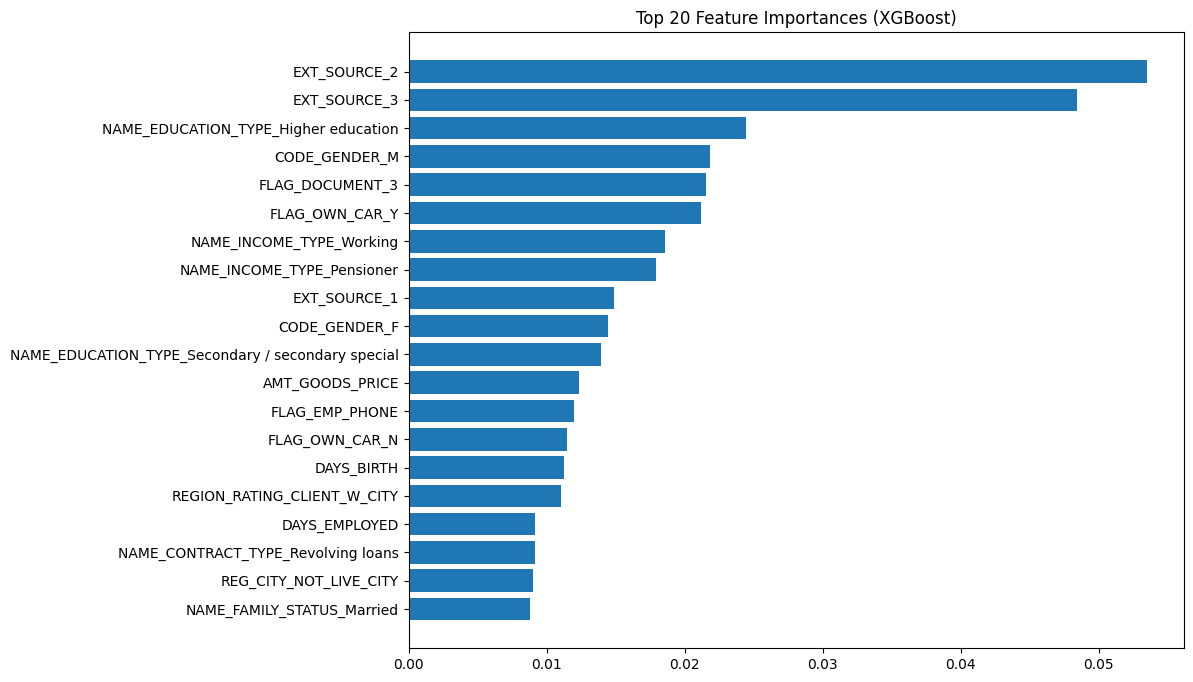

In [32]:
top_feats = feat_imp.head(20).sort_values('importance')

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.barh(top_feats['feature'], top_feats['importance'])
plt.title('Top 20 Feature Importances (XGBoost)')
plt.show()

The most important predictors of default risk are the external score variables (EXT_SOURCE_2 and EXT_SOURCE_3), which likely represent credit bureau or alternative risk scores. This is consistent with real-world credit modeling, where external credit assessments are highly informative.

Socioeconomic variables such as education level and income type also play a significant role, suggesting that financial stability and employment characteristics influence default probability.

Demographic variables such as age and family status contribute to the model, although these should be interpreted cautiously as they may act as proxies for underlying financial behavior rather than direct causal factors.

Asset-related indicators, such as car ownership, and regional variables also appear among the top predictors, reflecting broader economic conditions and borrower characteristics.

Overall, the feature importance results align well with expected drivers of credit risk.

**Conclusion:**

This project developed a machine learning pipeline to predict borrower default risk using the Home Credit dataset.

A baseline Logistic Regression model provided solid performance and interpretability, while XGBoost improved predictive power by capturing nonlinear relationships.

Model evaluation highlighted the importance of using appropriate metrics for imbalanced data, such as ROC-AUC and precision-recall AUC.

Threshold analysis demonstrated that classification decisions must be aligned with business objectives, as different thresholds produce different trade-offs between missed defaults and false positives.

Feature importance analysis showed that external credit scores are the strongest predictors, alongside socioeconomic and demographic variables.

Future improvements could include incorporating additional relational datasets, hyperparameter tuning, and model calibration.